Playing around with PyTorch MRI datasets and image segmentation.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import time

from medsegbench import Promise12MSBench
from scipy.ndimage import distance_transform_edt

import torch
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
# Load Promise12 MRI prostate segmentation dataset from MedSegBench
train_images = Promise12MSBench(split="train", download=True, size=128)
val_images = Promise12MSBench(split="val", download=True, size=128)

print(f"Training set size: {len(train_images)}")
print(f"Validation set size: {len(val_images)}")

Training set size: 1031
Validation set size: 147


Sample 0: Image shape: (128, 128), Mask shape: (128, 128)


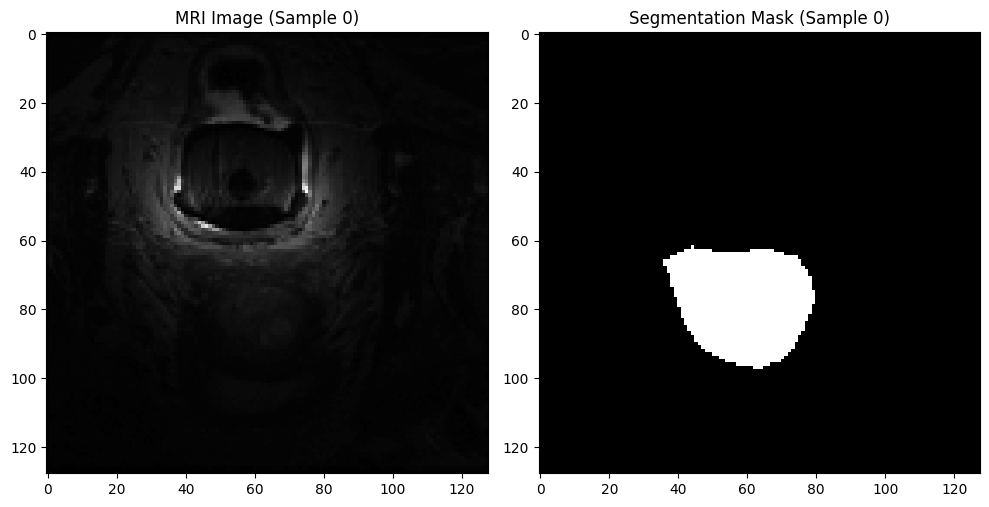

Sample 1: Image shape: (128, 128), Mask shape: (128, 128)


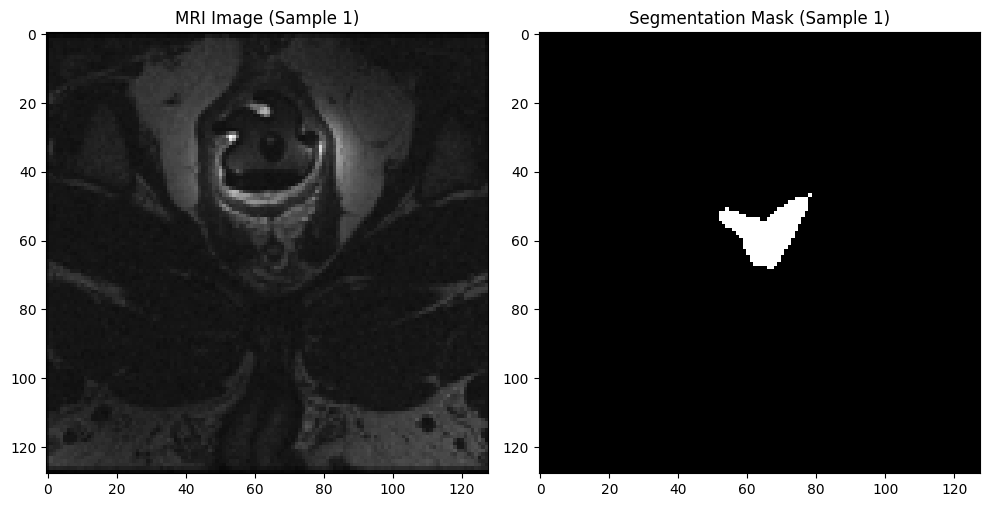

In [29]:
# Display sample images from training data
for i in range(2):
    image, mask = train_images[i] # Image is a PIL Image, mask is a numpy array
    
    print(f"Sample {i}: Image shape: {image.size}, Mask shape: {mask.shape}")
       
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(f'MRI Image (Sample {i})')
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(f'Segmentation Mask (Sample {i})')
    plt.tight_layout()
    plt.show()

In [3]:
# Currently we have training and validation data in the form of PIL images and numpy array masks
# Let's get ready to train a model by converting them to tensors

class MRIDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, mask = self.base_dataset[idx]
        # Convert PIL image to tensor and normalize, add channel dimension
        image.convert("L")  # Ensure grayscale
        image = torch.tensor(np.array(image), dtype=torch.float32).unsqueeze(0) / 255.0
        # Convert mask to binary: any non-zero value becomes 1 (as float for BCE loss)
        mask = torch.tensor((mask > 0).astype(np.float32), dtype=torch.float32).unsqueeze(0)
        return image, mask
    
# Wrap the datasets
train_dataset = MRIDataset(train_images)
val_dataset = MRIDataset(val_images)

# Create dataloaders - this is where we set batch size and shuffling
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
# print(f"Training set size: {len(train_dataset)}")
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
# print(f"Validation set size: {len(val_dataset)}")

In [4]:
# Let's set up a simple UNet model for segmentation
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Define the convoltuional layers, including batch normalization and ReLU activation at each step
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )
        
        # Apply a few encoding layers with pooling
        self.enc1 = conv_block(1, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = conv_block(64, 128)
        
        # Decode back to a single channel using convolutions as well
        # self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = conv_block(128 + 64, 64)
        # self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = conv_block(64 + 32, 32)

        self.final = nn.Conv2d(32, 1, kernel_size=1)

    # Apply each block defined above in sequence
    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        b = self.bottleneck(p2)

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

model = SimpleUNet()

# Check the properties of the model such as the number of tunable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters in the model: {total_params}")

Total trainable parameters in the model: 472257


In [25]:
# Loss function components

# BCE with pos_weight to penalize false negatives (background bias)
# pos_weight > 1 gives more weight to positive class (prostate), helping with class imbalance
# bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]))
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(logits, target, eps=1e-7):
    """
    MEASURE OF OVERLAP BETWEEN TWO SAMPLES. IT RANGES FROM 0 TO 1, WHERE 1 MEANS PERFECT OVERLAP AND 0 MEANS NO OVERLAP
     
    logits: (B, 1, H, W) raw outputs
    target: (B, 1, H, W) binary masks
    eps: small constant to avoid division by zero
    """
    prob = logits.sigmoid()
    prob   = prob.view(prob.size(0), -1)
    target = target.view(target.size(0), -1)
    intersection = (prob * target).sum(dim=1) # Implement dice loss per-sample (sum over specific dimension)
    union = prob.sum(dim=1) + target.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean() # Subtract from 1 to convert to a loss (we want to maximize dice)


### BOUNDARY-SPECIFIC LOSS FUNCTION CONTRIBUTIONS ###

# Start with a function that maps the distance to the boundary of each pixel given the mask
def distance_transform(mask):
    """
    DISTANCE TRANSFORM SEPARATELY FOR INSIDE AND OUTSIDE OF THE MASK, WHICH CAN BE USED TO CONSTRUCT THE SIGNED DISTANCE MAP

    mask_np: (H, W) binary {0,1}
    returns: (H, W) tuple of (distance outside, distance inside)
    """

    fg_dt = distance_transform_edt(mask == 0)
    bg_dt = distance_transform_edt(mask == 1)
    return fg_dt, bg_dt  # outside DT, inside DT


def signed_distance_map(mask):
    """
    MAPS EACH PIXEL TO THE NEAREST BOUNDARY OF THE MASK, WITH SIGN INDICATING INSIDE/OUTSIDE
    
    mask_np: (H, W) binary {0,1}
    returns: (H, W) signed distance map (positive outside, negative inside)
    """
    fg_dt, bg_dt = distance_transform(mask)
    sdf = fg_dt - bg_dt
    return sdf.astype(np.float32)


def boundary_loss_from_logits(logits, sdf, max_dist=20.0):
    """
    BOUNDARY LOSS GIVEN LOGITS (WHICH ARE THE RAW MODEL OUTPUTS) AND THE SIGNED DISTANCE MAP
    
    logits: (B, 1, H, W) raw outputs
    sdf:    (B, 1, H, W) signed distance map (float)
    max_dist: maximum distance from boundary to consider for normalization (so pixel far from the boundary do not dominate the loss)
    """
    probs = torch.sigmoid(logits)
    sdf = torch.clamp(sdf, -max_dist, max_dist) / max_dist  # now in [-1, 1]
    # boundary loss is mean of p(x) * sdf(x)
    return torch.mean(probs * sdf)


def boundary_band_loss(logits, target, sdf, max_dist=20.0):
    """
    BOUNDARY THAT EMPHASIZES ERRORS NEAR THE BOUNDARY, WHICH IS WHERE THE ISSUES TEND TO BE
    
    logits: (B, 1, H, W) raw outputs
    sdf:    (B, 1, H, W) signed distance map (float)
    max_dist: maximum distance from boundary to consider for normalization (so pixel far from the boundary do not dominate the loss)
    """
    probs = torch.sigmoid(logits)
    # weights high near boundary (distance ~0), low far away
    w = 1.0 - torch.clamp(torch.abs(sdf), 0, max_dist) / max_dist  # in [0,1]
    # focus on mistakes near boundary
    return torch.mean(w * torch.abs(probs - target))



def hausdorff_dt_loss(logits, targets, fg_dt, bg_dt):
    """
    HAUSDORFF DISTANCE-BASED LOSS THAT PENALIZES FALSE POSITIVES AND FALSE NEGATIVES BASED ON THEIR DISTANCE TO THE TRUE BOUNDARY.
    GOOD AT ADDRESSING WHEN "CHUNKS" OF THE SEGMENTATION ARE MISSING OR EXTRA.

    logits: (B,1,H,W)
    targets:   (B,1,H,W) binary mask
    fg_dt:  (B,1,H,W) distance-transform outside the foreground (FN penalty field)
    bg_dt:  (B,1,H,W) distance-transform inside the foreground (FP penalty field)
    """
    probs = torch.sigmoid(logits)

    # Convert targets to numpy for distance transform calculations
    # targets = targets.detach().cpu().numpy()

    # false positives: predict 1 where targets = 0
    fp = probs * (1 - targets)
    # false negatives: predict 0 where targets = 1
    fn = (1 - probs) * targets

    # Convert distance map numpy arrays to tensors
    fg_dt = torch.tensor(fg_dt, dtype=torch.float32)
    bg_dt = torch.tensor(bg_dt, dtype=torch.float32)
    
    loss_fp = (fp * fg_dt).mean()
    loss_fn = (fn * bg_dt).mean()

    return loss_fp + loss_fn


# Combine BCE, Dice, and Boundary losses
def combined_loss(logits, targets, bce_weight=1.0, dice_weight=1.0, boundary_weight=1.0):
    """ COMBINATION OF DIFFERENT CONTRIBUTIONS TO THE LOSS FUNCTION WITH WEIGHTS SPECIFIED """
    bce = bce_loss(logits, targets)
    dice = dice_loss(logits, targets)

    fg_dt, bg_dt = distance_transform(targets.detach().cpu().numpy().squeeze(1))  # (B,H,W) numpy arrays
    bndry_loss = hausdorff_dt_loss(logits, targets, fg_dt, bg_dt)

    # sdf = fg_dt - bg_dt  # (B,H,W) signed distance map
    # bndry_loss = boundary_band_loss(logits, targets, sdf)

    return bce_weight * bce + dice_weight * dice + boundary_weight * bndry_loss


In [26]:
# Training and evaluation

# Loss function with pos_weight to penalize false negatives (background bias)
# pos_weight > 1 gives more weight to positive class (prostate), helping with class imbalance
# criterion = bce_dice_loss()
# Set up the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
num_epochs = 10
start_time = time.time()
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, masks in train_loader:
        optimizer.zero_grad() # Reset gradients at each step

        outputs = model(images) # Calculate model outputs

        # Update weight of boundary loss term based on a schedule
        bdy_weight = min(2.0, epoch/2.5) # Works itself up to 1 over first 5 epochs

        loss = combined_loss(outputs, masks, boundary_weight=bdy_weight)
        loss.backward() # Differentiate loss function
        optimizer.step() # Update model parameters
        
        running_loss += loss.item() # Accumulate loss from each image
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")
    training_time = time.time() - start_time
    print(f"Total time: {int(training_time // 60)}m{int(training_time % 60)}s")

# Save the trained model
torch.save(model.state_dict(), 'model.pth')

Epoch 1, Loss: 1.2617812083317683
Total time: 1m58s
Epoch 2, Loss: 2.116168132195106
Total time: 3m50s
Epoch 3, Loss: 1.2819448122611412
Total time: 6m1s
Epoch 4, Loss: 0.7837759971618652
Total time: 7m44s
Epoch 5, Loss: 0.5674250964935009
Total time: 9m37s
Epoch 6, Loss: 0.5198826954914973
Total time: 11m29s
Epoch 7, Loss: 0.3560458540916443
Total time: 13m12s
Epoch 8, Loss: 0.31774494647979734
Total time: 15m7s
Epoch 9, Loss: 0.28041041722664467
Total time: 17m4s
Epoch 10, Loss: 0.25375595482496116
Total time: 18m51s


In [27]:
# Load the model

model = SimpleUNet()
model.load_state_dict(torch.load('./model.pth'))

<All keys matched successfully>

In [11]:
# Evaluate the model on training and validation data

model.eval()
train_loss = 0.0
val_loss = 0.0
running_accuracy_val = 0.0
running_accuracy_train = 0.0
with torch.no_grad(): # Since we are not training, no need to calculate grad
    for images, masks in train_loader:
        outputs = model(images)
        sdf = torch.stack([torch.tensor(signed_distance_map(mask.squeeze().numpy())) for mask in masks]).unsqueeze(1)
        loss = combined_loss(outputs, masks, sdf)
        train_loss += loss.item() # Loss function on training set

        # We want to calculate accuracy as well
        # The outputs are logits, apply sigmoid and threshold at 0.5
        predicted = torch.sigmoid(outputs).float()
        predicted = (predicted > 0.5).squeeze(1).float()  # Binarize predictions
        correct = (predicted == masks.squeeze(1)).sum().item()
        total = masks.numel()
        accuracy = correct / total
        running_accuracy_train += accuracy

    for images, masks in val_loader:
        outputs = model(images)
        sdf = torch.stack([torch.tensor(signed_distance_map(mask.squeeze().numpy())) for mask in masks]).unsqueeze(1)
        loss = combined_loss(outputs, masks, sdf)
        val_loss += loss.item() # Loss function on validation set

        # We want to calculate accuracy as well
        # The outputs are logits, apply sigmoid and threshold at 0.5
        predicted = torch.sigmoid(outputs).float()
        predicted = (predicted > 0.5).squeeze(1).float()  # Binarize predictions
        correct = (predicted == masks.squeeze(1)).sum().item()
        total = masks.numel()
        accuracy = correct / total
        running_accuracy_val += accuracy   

print(f"Training Loss: {train_loss/len(train_loader):.4f}")
# Divide summed accuracy by number of batches to get overall accuracy
train_accuracy = running_accuracy_train / len(train_loader)
print(f"Training Accuracy: {train_accuracy*100:.2f}%")

print(f"Validation Loss: {val_loss/len(val_loader):.4f}")
val_accuracy = running_accuracy_val / len(val_loader)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

Training Loss: 0.2173
Training Accuracy: 99.30%
Validation Loss: 0.2457
Validation Accuracy: 99.19%


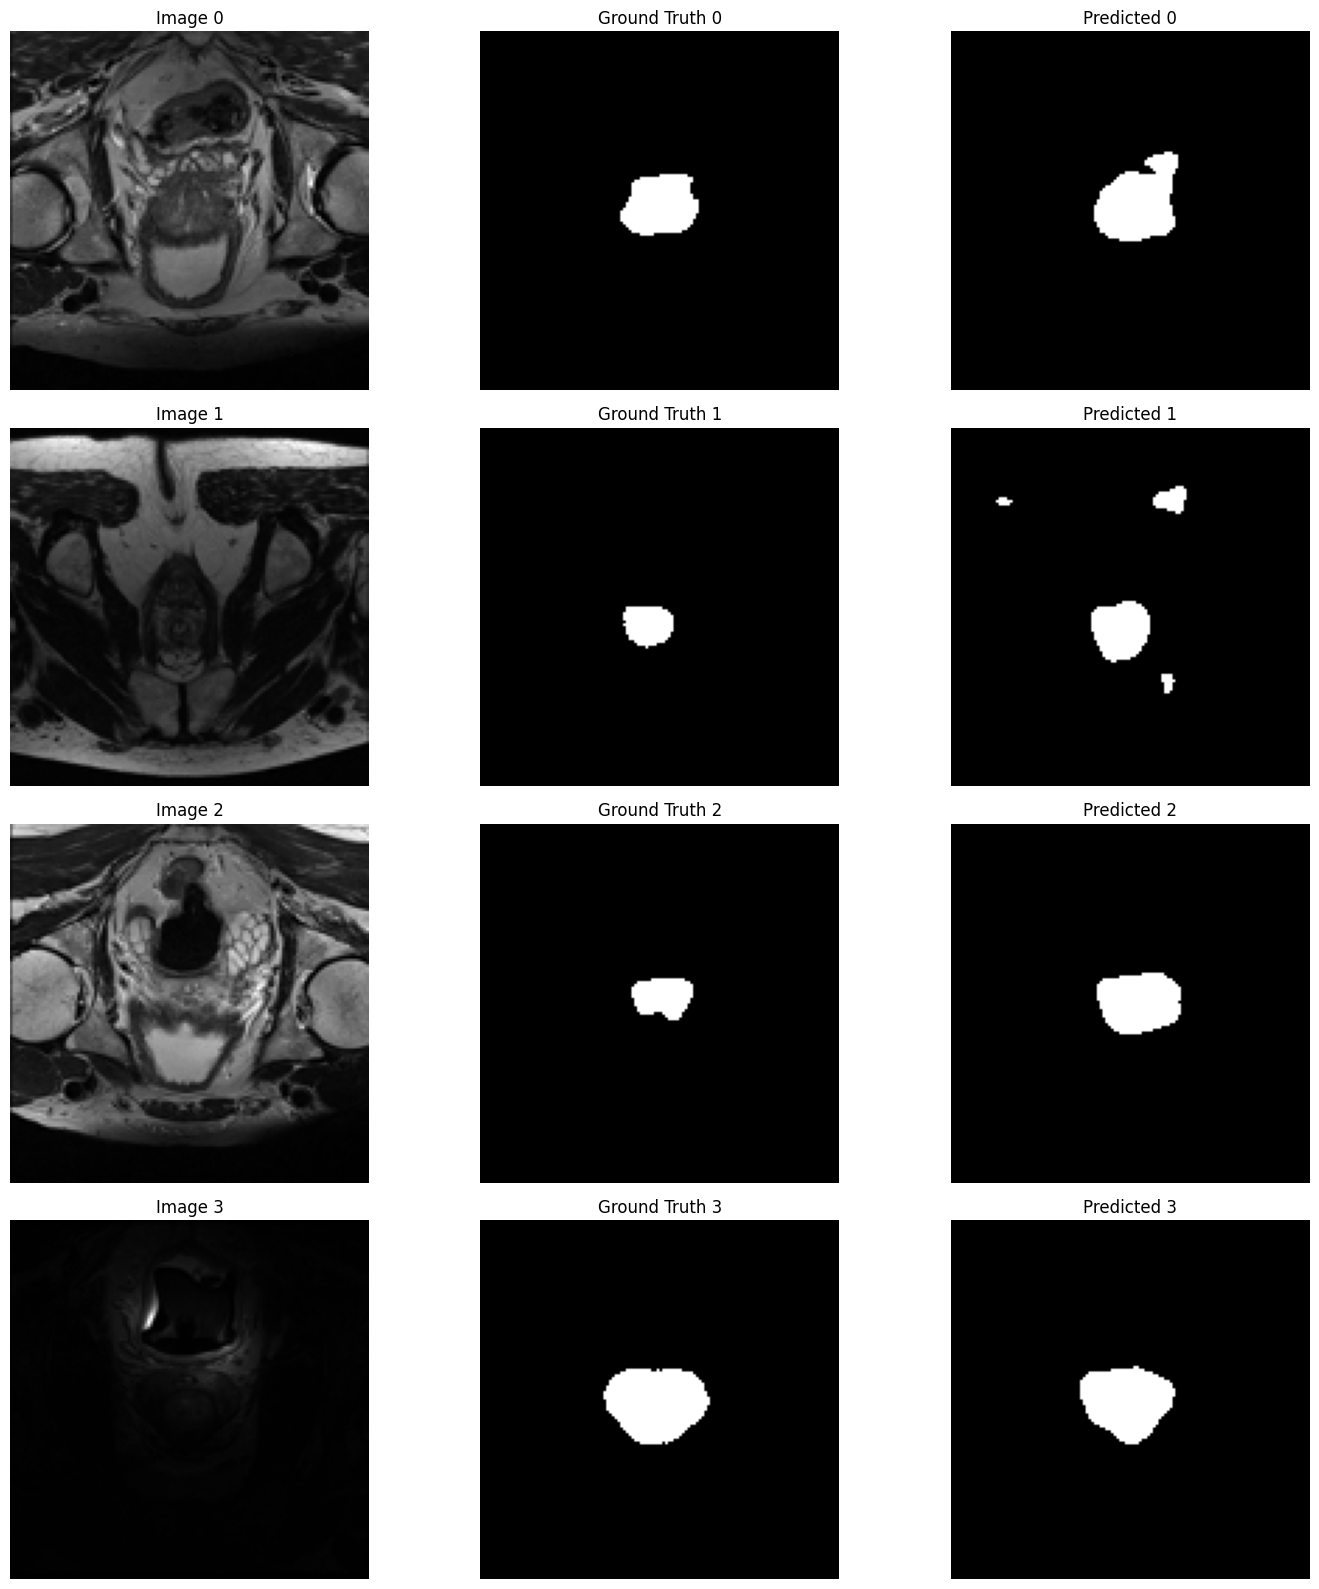

In [28]:
# Visualize predictions on validation set
num_samples = 4

fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))

with torch.no_grad():
    for idx in range(num_samples):
        image, mask = val_dataset[idx]
        
        # Add batch dimension and get prediction
        image_batch = image.unsqueeze(0)
        output = model(image_batch)
        
        # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
        predicted_mask = torch.sigmoid(output).squeeze(0).squeeze(0).numpy()
        predicted_mask = (predicted_mask > 0.5).astype(np.uint8)

        # Convert to numpy for display
        image_np = image.squeeze(0).numpy()
        mask_np = mask.squeeze(0).numpy()
        
        # Display
        axes[idx, 0].imshow(image_np, cmap='gray')
        axes[idx, 0].set_title(f'Image {idx}')
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(mask_np, cmap='gray')
        axes[idx, 1].set_title(f'Ground Truth {idx}')
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(predicted_mask, cmap='gray')
        axes[idx, 2].set_title(f'Predicted {idx}')
        axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()


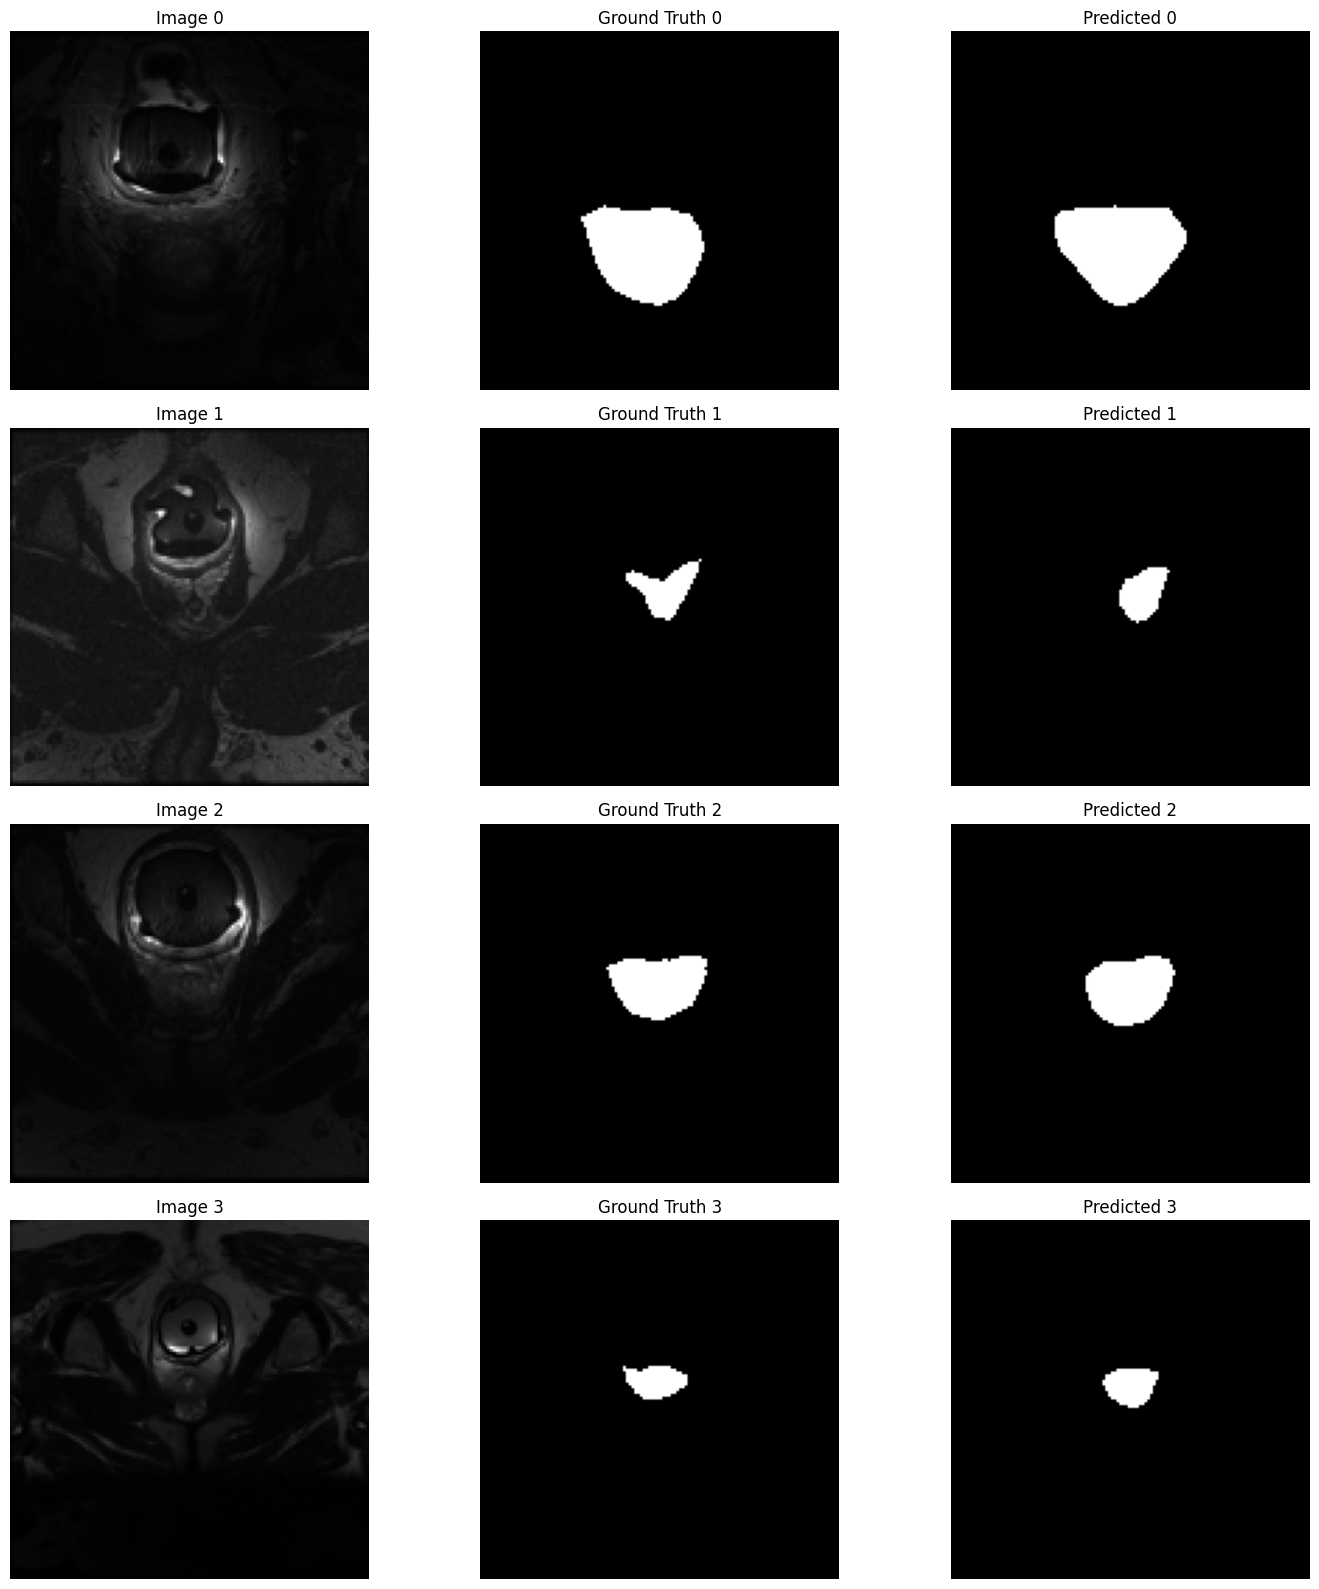

In [24]:
# Visualize predictions on training set

num_samples = 4

fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))

with torch.no_grad():
    for idx in range(num_samples):
        image, mask = train_dataset[idx]
        
        # Add batch dimension and get prediction
        image_batch = image.unsqueeze(0)
        output = model(image_batch)
        
        # Get predicted class (apply sigmoid and threshold at 0.5)
        predicted_mask = torch.sigmoid(output).squeeze(0).squeeze(0).numpy()
        predicted_mask = (predicted_mask > 0.5).astype(np.uint8)
        
        # Convert to numpy for display
        image_np = image.squeeze(0).numpy()
        mask_np = mask.squeeze(0).numpy()
        
        # Display
        axes[idx, 0].imshow(image_np, cmap='gray')
        axes[idx, 0].set_title(f'Image {idx}')
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(mask_np, cmap='gray')
        axes[idx, 1].set_title(f'Ground Truth {idx}')
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(predicted_mask, cmap='gray')
        axes[idx, 2].set_title(f'Predicted {idx}')
        axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()